# Frequentist and Bayesian cosmological inference with the Pantheon$+$SH0ES Type Ia supernova sample

**EP4130 - Data Science Analysis (course project)**
Anirudh Saikrishnan

Single self-contained companion to `report.tex`.  Runs the full analysis from data ingest to figure
production.  Each section matches one section of the report.  Figures go to `figs/`, numeric summaries
to `results_*.txt`.  End-to-end run time ~2-3 min on a laptop (MCMC-dominated).

## How to run this notebook

```bash
# create a virtual environment and install dependencies
python -m venv .venv
.venv\Scripts\activate         # on Windows
# source .venv/bin/activate     # on macOS / Linux
pip install -r requirements.txt
python -m ipykernel install --user --name pantheon-venv
jupyter lab pantheon_analysis.ipynb
```

Then select the **pantheon-venv** kernel inside Jupyter and run the
cells top-to-bottom. The notebook expects `Pantheon+SH0ES.dat` to live
alongside it and writes all figures to `figs/`.


## 0. Setup and imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import minimize_scalar, minimize
from scipy.stats import chi2 as chi2_dist, norm, gaussian_kde
from scipy import stats
import emcee
import corner

plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25,
    "figure.dpi": 110, "savefig.bbox": "tight",
})
os.makedirs('figs', exist_ok=True)
print('numpy', np.__version__, ' emcee', emcee.__version__)

numpy 2.4.4  emcee 3.1.6


## 1. Load the Pantheon+SH0ES dataset

Read the official `Pantheon+SH0ES.dat` (1701 rows), drop the 77 SH0ES calibrators, require $z>0.01$.
Final sample N=1580 spanning $0.01 \le z \le 2.26$.

In [2]:
DATA_PATH_DEFAULT = "Pantheon+SH0ES.dat"


def load(path: str = DATA_PATH_DEFAULT,
         zmin: float = 0.01,
         drop_calibrators: bool = True):
    """Return (z, mb, sigma, df_selected) after quality cuts.

    Parameters
    ----------
    path : str
        Absolute path to Pantheon+SH0ES.dat
    zmin : float
        Minimum Hubble-diagram redshift.
    drop_calibrators : bool
        If True, drop SN Cepheid calibrator entries (77 rows).
    """
    df = pd.read_csv(path, sep=r"\s+")
    mask = np.ones(len(df), dtype=bool)
    if drop_calibrators:
        mask &= df["IS_CALIBRATOR"].values == 0
    mask &= df["zHD"].values > zmin
    sel = df.loc[mask].reset_index(drop=True)
    z  = sel["zHD"].values.astype(float)
    mb = sel["m_b_corr"].values.astype(float)
    sb = sel["m_b_corr_err_DIAG"].values.astype(float)
    return z, mb, sb, sel


z, mb, sb, df = load()
print(f"sample size N = {len(z)},  unique CIDs = {df['CID'].nunique()}")
print(f"z range [{z.min():.4f}, {z.max():.4f}]  median z = {np.median(z):.4f}")

sample size N = 1580,  unique CIDs = 1466
z range [0.0102, 2.2614]  median z = 0.1852


## 2. Cosmological models and marginalised likelihood

Three models: flat ΛCDM, wCDM, open ΛCDM.  $M$-marginalised $\chi^2$:
$\chi^2_{\rm marg}(\theta) = A - B^2/C$.  Distances pre-computed on a shared 8192-pt grid.

In [3]:
C_KM_S = 299792.458
H0_FIDUCIAL_H = 0.70

def E_flat_lcdm(z, Om):
    return np.sqrt(Om * (1.0 + z) ** 3 + (1.0 - Om))

def E_wcdm(z, Om, w):
    zp1 = 1.0 + z
    return np.sqrt(Om * zp1 ** 3 + (1.0 - Om) * zp1 ** (3.0 * (1.0 + w)))

def E_open_lcdm(z, Om, OL):
    Ok = 1.0 - Om - OL
    return np.sqrt(Om * (1.0 + z) ** 3 + Ok * (1.0 + z) ** 2 + OL)

def _comoving_int(z, E_func, args):
    z = np.atleast_1d(z)
    order = np.argsort(z)
    zs = z[order]
    N_grid = 8192
    zgrid = np.linspace(0.0, max(zs.max(), 1e-6), N_grid)
    integrand = 1.0 / E_func(zgrid, *args)
    cum = np.concatenate([[0.0],
                          np.cumsum(0.5 * (integrand[1:] + integrand[:-1])
                                    * np.diff(zgrid))])
    val = np.interp(zs, zgrid, cum)
    out = np.empty_like(zs)
    out[order] = val
    return out

def mu_model(z, model, params, h=H0_FIDUCIAL_H):
    if model == 'flat_lcdm':
        (Om,) = params
        Ok = 0.0
        E_fun, eargs = E_flat_lcdm, (Om,)
    elif model == 'wcdm':
        Om, w = params
        Ok = 0.0
        E_fun, eargs = E_wcdm, (Om, w)
    elif model == 'open_lcdm':
        Om, OL = params
        Ok = 1.0 - Om - OL
        E_fun, eargs = E_open_lcdm, (Om, OL)
    else:
        raise ValueError(f"unknown model: {model}")
    H0 = 100.0 * h
    DH = C_KM_S / H0
    chi = DH * _comoving_int(z, E_fun, eargs)
    if abs(Ok) < 1e-8:
        dC = chi
    elif Ok > 0:
        sqOk = np.sqrt(Ok)
        dC = DH / sqOk * np.sinh(sqOk * chi / DH)
    else:
        sqOk = np.sqrt(-Ok)
        dC = DH / sqOk * np.sin(sqOk * chi / DH)
    dL = (1.0 + z) * dC
    return 5.0 * np.log10(dL) + 25.0

def chi2_marg(z, mb, sigma, model, params):
    mu = mu_model(z, model, params)
    r = mb - mu
    inv_s2 = 1.0 / sigma ** 2
    A = np.sum(r ** 2 * inv_s2)
    B = np.sum(r * inv_s2)
    C = np.sum(inv_s2)
    return A - B ** 2 / C

def best_fit_M(z, mb, sigma, model, params):
    mu = mu_model(z, model, params)
    r = mb - mu
    inv_s2 = 1.0 / sigma ** 2
    return np.sum(r * inv_s2) / np.sum(inv_s2)

def chi2_withM(z, mb, sigma, model, params, M):
    mu = mu_model(z, model, params)
    return np.sum(((mb - mu - M) / sigma) ** 2)

def log_like_marg(z, mb, sigma, model, params):
    return -0.5 * chi2_marg(z, mb, sigma, model, params)

PARAM_NAMES = {
    'flat_lcdm': [r'\Omega_m'],
    'wcdm':      [r'\Omega_m', 'w'],
    'open_lcdm': [r'\Omega_m', r'\Omega_\Lambda'],
}
NDIM = {'flat_lcdm': 1, 'wcdm': 2, 'open_lcdm': 2}

PRIOR_RANGES = {
    r'\Omega_m':       (0.0, 1.0),
    'w':                (-2.5, 0.0),
    r'\Omega_\Lambda':(0.0, 1.5),
}

def uniform_log_prior(params, names):
    for p, n in zip(params, names):
        lo, hi = PRIOR_RANGES[n]
        if not (lo < p < hi):
            return -np.inf
    return 0.0

## 3. Exploratory data analysis: the Hubble diagram

Saved fig_hubble_diagram.pdf / .png

-- EDA summary --
N                       : 1580
unique CIDs in selection: 1466
z range                 : [0.0102, 2.2614]
median z                : 0.1852
m_b_corr range          : [13.53, 26.93]
median sigma_mb         : 0.212 mag
M_BF (Om=0.334)         : -19.3494
res: mean, std          : +0.0073, 0.1531
reduced chi2 vs ref     : 0.440


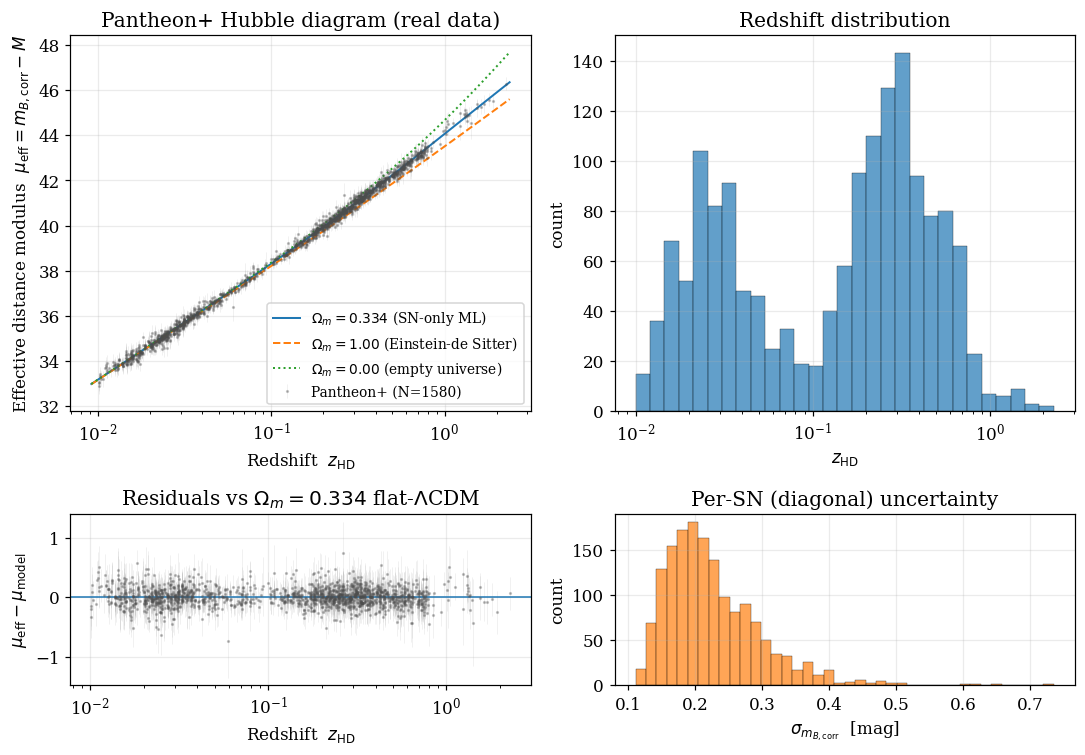

In [4]:
z, mb, sb, df = load()
OM_REF = 0.334
M_REF = best_fit_M(z, mb, sb, 'flat_lcdm', (OM_REF,))
mu_eff = mb - M_REF

fig, axs = plt.subplots(2, 2, figsize=(10.0, 7.0),
                        gridspec_kw=dict(height_ratios=[2.2, 1]))
ax1, ax2, ax3, ax4 = axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]

zg = np.logspace(np.log10(z.min() * 0.9), np.log10(z.max() * 1.05), 400)

ax1.errorbar(z, mu_eff, yerr=sb, fmt='.', ms=2.2, alpha=0.30, color='0.3',
             ecolor='0.7', elinewidth=0.4, label=f'Pantheon+ (N={len(z)})')
for (Om, ls, lbl) in [(0.334, '-',  r'$\Omega_m=0.334$ (SN-only ML)'),
                      (1.000, '--', r'$\Omega_m=1.00$ (Einstein-de Sitter)'),
                      (0.000, ':',  r'$\Omega_m=0.00$ (empty universe)')]:
    ax1.plot(zg, mu_model(zg, 'flat_lcdm', (Om,)), ls, lw=1.3, label=lbl)
ax1.set_xscale('log')
ax1.set_xlabel(r'Redshift  $z_{\rm HD}$')
ax1.set_ylabel(r'Effective distance modulus  $\mu_{\rm eff} = m_{B,\rm corr} - M$')
ax1.set_title('Pantheon+ Hubble diagram (real data)')
ax1.legend(fontsize=9, loc='lower right')

mu_ref = mu_model(z, 'flat_lcdm', (OM_REF,))
res = mu_eff - mu_ref
ax3.errorbar(z, res, yerr=sb, fmt='.', ms=2.2, alpha=0.30, color='0.3',
             ecolor='0.7', elinewidth=0.4)
ax3.axhline(0.0, color='C0', lw=1)
ax3.set_xscale('log')
ax3.set_xlabel(r'Redshift  $z_{\rm HD}$')
ax3.set_ylabel(r'$\mu_{\rm eff} - \mu_{\rm model}$')
ax3.set_title(r'Residuals vs $\Omega_m=0.334$ flat-$\Lambda$CDM')

ax2.hist(z, bins=np.logspace(np.log10(0.01), np.log10(2.3), 30),
         color='C0', alpha=0.7, edgecolor='k', lw=0.3)
ax2.set_xscale('log')
ax2.set_xlabel(r'$z_{\rm HD}$')
ax2.set_ylabel('count')
ax2.set_title('Redshift distribution')

ax4.hist(sb, bins=40, color='C1', alpha=0.7, edgecolor='k', lw=0.3)
ax4.set_xlabel(r'$\sigma_{m_{B,\rm corr}}$  [mag]')
ax4.set_ylabel('count')
ax4.set_title('Per-SN (diagonal) uncertainty')

fig.tight_layout()
fig.savefig('figs/fig_hubble_diagram.pdf')
fig.savefig('figs/fig_hubble_diagram.png', dpi=150)
print("Saved fig_hubble_diagram.pdf / .png")

rchi2 = np.sum((res / sb) ** 2) / (len(z) - 2)
print("\n-- EDA summary --")
print(f"N                       : {len(z)}")
print(f"unique CIDs in selection: {df['CID'].nunique()}")
print(f"z range                 : [{z.min():.4f}, {z.max():.4f}]")
print(f"median z                : {np.median(z):.4f}")
print(f"m_b_corr range          : [{mb.min():.2f}, {mb.max():.2f}]")
print(f"median sigma_mb         : {np.median(sb):.3f} mag")
print(f"M_BF (Om=0.334)         : {M_REF:.4f}")
print(f"res: mean, std          : {res.mean():+.4f}, {res.std():.4f}")
print(f"reduced chi2 vs ref     : {rchi2:.3f}")

with open('results_eda.txt', 'w') as f:
    f.write(
        f"N = {len(z)}\n"
        f"unique_CIDs = {df['CID'].nunique()}\n"
        f"z_min = {z.min():.4f}\n"
        f"z_max = {z.max():.4f}\n"
        f"z_median = {np.median(z):.4f}\n"
        f"median_sigma = {np.median(sb):.4f}\n"
        f"M_ref = {M_REF:.4f}\n"
        f"res_mean = {res.mean():.4f}\n"
        f"res_std = {res.std():.4f}\n"
        f"reduced_chi2_ref = {rchi2:.3f}\n"
    )
plt.show()

## 4. Frequentist analysis: profile $\chi^2$ and $\Delta\chi^2$ contours

flat LCDM  Om_hat = 0.3491   chi2_min = 694.15   N-1 = 1579
reduced chi2 = 0.440
1-sigma Om_hat = 0.3491 [0.3305, 0.3681]
2-sigma Om_hat = 0.3491 [0.3123, 0.3876]
3-sigma Om_hat = 0.3491 [0.2946, 0.4075]
Fisher 1-sigma (from quadratic fit) = 0.0188
Saved fig_freq_chi2.pdf / .png
wCDM ML  Om = 0.2975  w = -0.8800  chi2 = 693.78
Saved fig_freq_wcdm_contours.pdf / .png


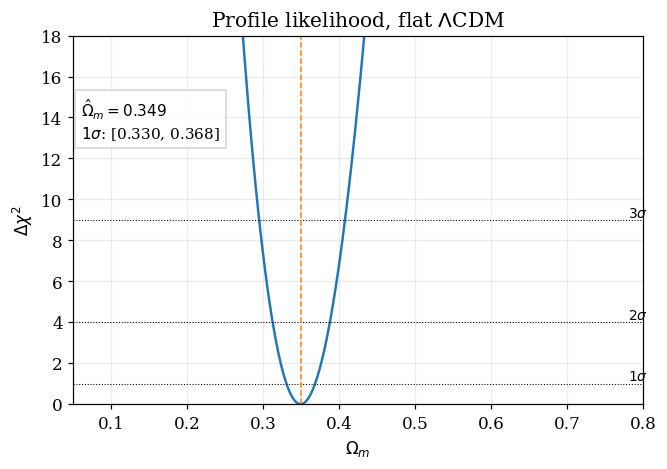

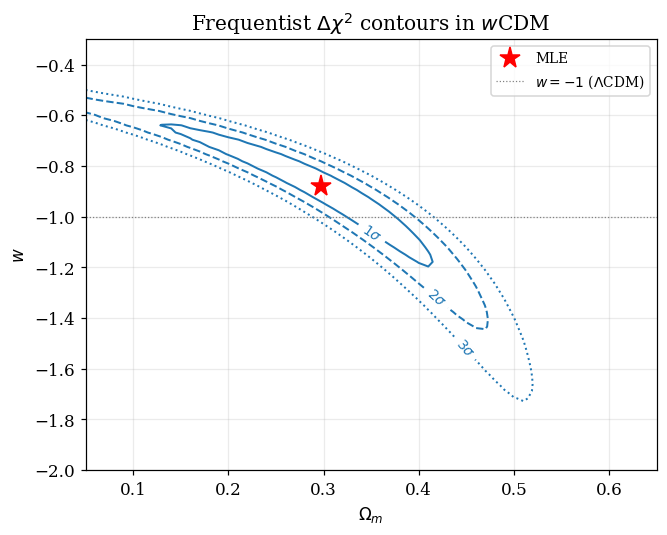

In [5]:
z, mb, sb, df = load()
N = len(z)

# -------- flat LCDM: 1-parameter profile chi^2 in Omega_m ----------------
def neg2lnL_flat(Om):
    return chi2_marg(z, mb, sb, 'flat_lcdm', (Om,))

res_flat = minimize_scalar(neg2lnL_flat, bounds=(1e-3, 0.9999),
                           method='bounded', options={'xatol': 1e-5})
Om_hat = res_flat.x
chi2_min = res_flat.fun
print(f"flat LCDM  Om_hat = {Om_hat:.4f}   chi2_min = {chi2_min:.2f}   N-1 = {N-1}")
print(f"reduced chi2 = {chi2_min / (N-1):.3f}")

# 1/2/3-sigma confidence limits on Omega_m (Wilks: Delta chi^2 = 1, 4, 9)
def find_root(f, a, b, tol=1e-5):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return None
    for _ in range(100):
        c = 0.5 * (a + b)
        fc = f(c)
        if fc * fa <= 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
        if b - a < tol:
            return 0.5 * (a + b)
    return 0.5 * (a + b)

Om_grid = np.linspace(0.05, 0.80, 251)
profile = np.array([neg2lnL_flat(o) for o in Om_grid])
Dchi2 = profile - chi2_min

limits = {}
for nsig, dc in [(1, 1.0), (2, 4.0), (3, 9.0)]:
    g_lo = find_root(lambda o: neg2lnL_flat(o) - chi2_min - dc,
                     0.001, Om_hat)
    g_hi = find_root(lambda o: neg2lnL_flat(o) - chi2_min - dc,
                     Om_hat, 0.999)
    limits[nsig] = (g_lo, g_hi)
    print(f"{nsig}-sigma Om_hat = {Om_hat:.4f} [{g_lo:.4f}, {g_hi:.4f}]")

# Hessian-based (asymptotic) covariance via quadratic fit near minimum
near = np.abs(Om_grid - Om_hat) < 0.05
p = np.polyfit(Om_grid[near], profile[near], 2)    # -2lnL = p0*x^2 + p1*x + p2
sigma_fisher = 1.0 / np.sqrt(p[0])                 # since Var = 2 / curvature_of_2lnL = 2/(2p0)=1/p0
print(f"Fisher 1-sigma (from quadratic fit) = {sigma_fisher:.4f}")

# -------- plot profile chi^2 ----------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(Om_grid, Dchi2, 'C0-', lw=1.6, label=r'profile $\Delta\chi^2(\Omega_m)$')
for nsig, dc in [(1, 1), (2, 4), (3, 9)]:
    ax.axhline(dc, color='k', ls=':', lw=0.7)
    ax.text(0.78, dc + 0.15, rf'${nsig}\sigma$', fontsize=9)
ax.axvline(Om_hat, color='C1', ls='--', lw=1)
ax.set_xlabel(r'$\Omega_m$')
ax.set_ylabel(r'$\Delta \chi^2$')
ax.set_title(r'Profile likelihood, flat $\Lambda$CDM')
ax.set_xlim(0.05, 0.80)
ax.set_ylim(0, 18)
ax.text(0.06, 15, rf'$\hat\Omega_m={Om_hat:.3f}$'
        + '\n'
        + rf'$1\sigma$: [{limits[1][0]:.3f}, {limits[1][1]:.3f}]',
        fontsize=10, va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.8'))
fig.tight_layout()
fig.savefig('figs/fig_freq_chi2.pdf')
fig.savefig('figs/fig_freq_chi2.png', dpi=150)
print("Saved fig_freq_chi2.pdf / .png")

# -------- wCDM: 2D Delta chi^2 contours in (Om, w) ------------------------
def neg2lnL_wcdm(theta):
    Om, w = theta
    if not (0.01 < Om < 0.99 and -2.5 < w < 0.0):
        return 1e10
    return chi2_marg(z, mb, sb, 'wcdm', (Om, w))

r_w = minimize(neg2lnL_wcdm, x0=[0.30, -1.0], method='Nelder-Mead',
               options={'xatol': 1e-4, 'fatol': 1e-4})
Om_w, w_hat = r_w.x
chi2_w = r_w.fun
print(f"wCDM ML  Om = {Om_w:.4f}  w = {w_hat:.4f}  chi2 = {chi2_w:.2f}")

# grid
Om_ax = np.linspace(0.05, 0.65, 61)
w_ax = np.linspace(-2.0, -0.3, 61)
OO, WW = np.meshgrid(Om_ax, w_ax)
GRID = np.zeros_like(OO)
for i in range(OO.shape[0]):
    for j in range(OO.shape[1]):
        GRID[i, j] = chi2_marg(z, mb, sb, 'wcdm', (OO[i, j], WW[i, j]))
Dgrid = GRID - chi2_w

fig, ax = plt.subplots(figsize=(6.2, 5.0))
levels = [2.30, 6.17, 11.83]  # 1,2,3-sigma for 2 dof
cs = ax.contour(OO, WW, Dgrid, levels=levels,
                colors=['C0', 'C0', 'C0'],
                linestyles=['-', '--', ':'], linewidths=1.3)
fmt = {2.30: r'$1\sigma$', 6.17: r'$2\sigma$', 11.83: r'$3\sigma$'}
ax.clabel(cs, fmt=fmt, inline=True, fontsize=9)
ax.plot(Om_w, w_hat, 'r*', ms=14, label='MLE')
ax.axhline(-1.0, color='0.5', ls=':', lw=0.8, label=r'$w=-1$ ($\Lambda$CDM)')
ax.set_xlabel(r'$\Omega_m$')
ax.set_ylabel(r'$w$')
ax.set_title(r'Frequentist $\Delta\chi^2$ contours in $w$CDM')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout()
fig.savefig('figs/fig_freq_wcdm_contours.pdf')
fig.savefig('figs/fig_freq_wcdm_contours.png', dpi=150)
print("Saved fig_freq_wcdm_contours.pdf / .png")

# -------- dump results ----------------------------------------------------
with open('results_frequentist.txt', 'w') as f:
    f.write(
        f"flat_lcdm_Om_hat = {Om_hat:.4f}\n"
        f"flat_lcdm_chi2_min = {chi2_min:.3f}\n"
        f"flat_lcdm_reduced_chi2 = {chi2_min/(N-1):.4f}\n"
        f"flat_lcdm_sigma_fisher = {sigma_fisher:.4f}\n"
        f"flat_lcdm_1sig_lo = {limits[1][0]:.4f}\n"
        f"flat_lcdm_1sig_hi = {limits[1][1]:.4f}\n"
        f"flat_lcdm_2sig_lo = {limits[2][0]:.4f}\n"
        f"flat_lcdm_2sig_hi = {limits[2][1]:.4f}\n"
        f"flat_lcdm_3sig_lo = {limits[3][0]:.4f}\n"
        f"flat_lcdm_3sig_hi = {limits[3][1]:.4f}\n"
        f"wcdm_Om_hat = {Om_w:.4f}\n"
        f"wcdm_w_hat = {w_hat:.4f}\n"
        f"wcdm_chi2_min = {chi2_w:.3f}\n"
        f"N = {N}\n"
    )
plt.show()

## 5. Bayesian MCMC with `emcee`

Three affine-invariant samplings (flat ΛCDM, wCDM, open ΛCDM).  Chains saved as
`.npy` files and used for the posterior plots and for the Savage-Dickey ratios later.

In [6]:
np.random.seed(42)
def log_post_flat(theta):
    lp = uniform_log_prior(theta, PARAM_NAMES['flat_lcdm'])
    if not np.isfinite(lp): return -np.inf
    return lp + log_like_marg(z, mb, sb, 'flat_lcdm', theta)
nwalk, ndim = 24, 1
p0 = np.clip(0.3 + 0.1 * np.random.randn(nwalk, ndim), 0.05, 0.95)
sampler_flat = emcee.EnsembleSampler(nwalk, ndim, log_post_flat)
state = sampler_flat.run_mcmc(p0, 300, progress=False); sampler_flat.reset()
sampler_flat.run_mcmc(state, 1500, progress=False)
tau_f = sampler_flat.get_autocorr_time(tol=0)
chain_flat = sampler_flat.get_chain(discard=200, thin=max(1, int(np.mean(tau_f)/2)), flat=True)
np.save('chain_flat.npy', chain_flat)
print(f"flat LCDM: N={len(chain_flat)}, acc={np.mean(sampler_flat.acceptance_fraction):.3f}, tau={tau_f}")

np.random.seed(7)
def log_post_wcdm(theta):
    lp = uniform_log_prior(theta, PARAM_NAMES['wcdm'])
    if not np.isfinite(lp): return -np.inf
    return lp + log_like_marg(z, mb, sb, 'wcdm', theta)
nw, nd = 24, 2
p0 = np.column_stack([0.30 + 0.04*np.random.randn(nw), -1.0 + 0.15*np.random.randn(nw)])
p0[:, 0] = np.clip(p0[:, 0], 0.05, 0.9); p0[:, 1] = np.clip(p0[:, 1], -2.4, -0.05)
sampler_w = emcee.EnsembleSampler(nw, nd, log_post_wcdm)
state = sampler_w.run_mcmc(p0, 400, progress=False); sampler_w.reset()
sampler_w.run_mcmc(state, 2500, progress=False)
chain_wcdm = sampler_w.get_chain(discard=200, flat=True)
np.save('chain_wcdm.npy', chain_wcdm)
print(f"wCDM:      N={len(chain_wcdm)}, acc={np.mean(sampler_w.acceptance_fraction):.3f}")

np.random.seed(11)
def log_post_open(theta):
    lp = uniform_log_prior(theta, PARAM_NAMES['open_lcdm'])
    if not np.isfinite(lp): return -np.inf
    return lp + log_like_marg(z, mb, sb, 'open_lcdm', theta)
p0o = np.column_stack([0.30 + 0.04*np.random.randn(nw), 0.70 + 0.10*np.random.randn(nw)])
p0o[:, 0] = np.clip(p0o[:, 0], 0.05, 0.9); p0o[:, 1] = np.clip(p0o[:, 1], 0.05, 1.4)
sampler_o = emcee.EnsembleSampler(nw, nd, log_post_open)
state = sampler_o.run_mcmc(p0o, 400, progress=False); sampler_o.reset()
sampler_o.run_mcmc(state, 2500, progress=False)
chain_open = sampler_o.get_chain(discard=200, flat=True)
np.save('chain_open.npy', chain_open)
print(f"open LCDM: N={len(chain_open)}, acc={np.mean(sampler_o.acceptance_fraction):.3f}")

flat LCDM: N=2832, acc=0.814, tau=[22.84077972]
wCDM:      N=55200, acc=0.672
open LCDM: N=55200, acc=0.717


In [10]:
z, mb, sb, df = load()
chain_flat = np.load('chain_flat.npy')
chain_wcdm = np.load('chain_wcdm.npy')
chain_open = np.load('chain_open.npy')

if chain_flat.ndim == 1:
    chain_flat = chain_flat.reshape(-1, 1)

print("chain_flat:", chain_flat.shape)
print("chain_wcdm:", chain_wcdm.shape)
print("chain_open:", chain_open.shape)

# ---------------- flat LCDM summary ----------------------------
Om_samples = chain_flat[:, 0]
Om_med = np.median(Om_samples)
Om_lo, Om_hi = np.percentile(Om_samples, [15.865, 84.135])
print(f"flat LCDM: Om = {Om_med:.4f}  [{Om_lo:.4f}, {Om_hi:.4f}]")

# ---------------- wCDM summary ---------------------------------
Om_w_samples, w_samples = chain_wcdm[:, 0], chain_wcdm[:, 1]
Om_w_med = np.median(Om_w_samples)
Om_w_lo, Om_w_hi = np.percentile(Om_w_samples, [15.865, 84.135])
w_med = np.median(w_samples)
w_lo, w_hi = np.percentile(w_samples, [15.865, 84.135])
print(f"wCDM:    Om = {Om_w_med:.4f}  [{Om_w_lo:.4f}, {Om_w_hi:.4f}]")
print(f"          w = {w_med:.4f}  [{w_lo:.4f}, {w_hi:.4f}]")

# ---------------- open LCDM summary ----------------------------
Om_o_samples, OL_o_samples = chain_open[:, 0], chain_open[:, 1]
Om_o_med = np.median(Om_o_samples)
Om_o_lo, Om_o_hi = np.percentile(Om_o_samples, [15.865, 84.135])
OL_o_med = np.median(OL_o_samples)
OL_o_lo, OL_o_hi = np.percentile(OL_o_samples, [15.865, 84.135])
Ok_o = 1.0 - Om_o_samples - OL_o_samples
Ok_med = np.median(Ok_o)
Ok_lo, Ok_hi = np.percentile(Ok_o, [15.865, 84.135])
print(f"openLCDM: Om = {Om_o_med:.4f} [{Om_o_lo:.4f},{Om_o_hi:.4f}]")
print(f"          OL = {OL_o_med:.4f} [{OL_o_lo:.4f},{OL_o_hi:.4f}]")
print(f"          Ok = {Ok_med:.4f} [{Ok_lo:.4f},{Ok_hi:.4f}]")

# ---------------- Fig: flat LCDM posterior vs freq likelihood --
Om_grid = np.linspace(0.20, 0.50, 201)
dchi2 = np.array([chi2_marg(z, mb, sb, 'flat_lcdm', (o,)) for o in Om_grid])
dchi2 -= dchi2.min()
lik_rel = np.exp(-0.5 * dchi2)
lik_rel /= np.trapezoid(lik_rel, Om_grid)

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.hist(Om_samples, bins=60, density=True, alpha=0.55,
        color='C0', edgecolor='C0', lw=0.4,
        label='Bayesian posterior (flat prior)')
ax.plot(Om_grid, lik_rel, 'C3-', lw=1.6,
        label=r'frequentist $\mathcal{L}(\Omega_m)$ (profile)')
ax.axvline(Om_med, color='C0', ls='--', lw=1.1)
ax.axvspan(Om_lo, Om_hi, color='C0', alpha=0.15, lw=0)
ax.set_xlabel(r'$\Omega_m$')
ax.set_ylabel('density')
ax.set_title(r'flat $\Lambda$CDM: Bayesian posterior vs frequentist likelihood')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig('figs/fig_bayes_posterior.pdf')
fig.savefig('figs/fig_bayes_posterior.png', dpi=150)
plt.close(fig)
print("Saved fig_bayes_posterior.{pdf,png}")

# ---------------- Fig: wCDM corner -----------------------------
fig2 = corner.corner(chain_wcdm, labels=[r'$\Omega_m$', r'$w$'],
                     show_titles=True, title_fmt='.3f',
                     title_kwargs={'fontsize': 10},
                     quantiles=[0.16, 0.5, 0.84], bins=40, color='C0',
                     smooth=1.1, truth_color='C3', truths=[None, -1.0])
fig2.savefig('figs/fig_bayes_wcdm_corner.pdf')
fig2.savefig('figs/fig_bayes_wcdm_corner.png', dpi=150)
plt.close(fig2)
print("Saved fig_bayes_wcdm_corner.{pdf,png}")

# ---------------- Fig: open LCDM corner ------------------------
fig4 = corner.corner(chain_open, labels=[r'$\Omega_m$', r'$\Omega_\Lambda$'],
                     show_titles=True, title_fmt='.3f',
                     title_kwargs={'fontsize': 10},
                     quantiles=[0.16, 0.5, 0.84], bins=40, color='C2',
                     smooth=1.1)
# overlay flat-universe line Om + OL = 1
ax_joint = fig4.axes[2]  # lower-left 2D panel in a 2x2 corner grid
xs = np.linspace(0.0, 1.0, 100)
ax_joint.plot(xs, 1.0 - xs, 'k--', lw=0.9, alpha=0.7,
              label=r'$\Omega_k=0$')
ax_joint.legend(fontsize=8, loc='upper right')
fig4.savefig('figs/fig_bayes_open_corner.pdf')
fig4.savefig('figs/fig_bayes_open_corner.png', dpi=150)
plt.close(fig4)
print("Saved fig_bayes_open_corner.{pdf,png}")

# ---------------- Fig: Bayesian vs frequentist (Om,w) overlay --
fig3, ax3 = plt.subplots(figsize=(6.4, 5.1))

# 2D posterior contours from wCDM chain
H, xe, ye = np.histogram2d(Om_w_samples, w_samples, bins=60)
xc, yc = 0.5 * (xe[1:] + xe[:-1]), 0.5 * (ye[1:] + ye[:-1])
Hf = H.ravel()
sidx = np.argsort(Hf)[::-1]
csum = np.cumsum(Hf[sidx]) / Hf.sum()
lvl1 = Hf[sidx][np.searchsorted(csum, 0.683)]
lvl2 = Hf[sidx][np.searchsorted(csum, 0.955)]
XC, YC = np.meshgrid(xc, yc, indexing='ij')
ax3.contour(XC, YC, H, levels=[lvl2, lvl1],
            colors=['C0', 'C0'], linestyles=['--', '-'], linewidths=1.4)

# Frequentist Delta chi^2 surface (2 dof)
Om_ax = np.linspace(max(0.02, Om_w_samples.min() - 0.04),
                    min(0.95, Om_w_samples.max() + 0.04), 45)
w_ax = np.linspace(max(-2.4, w_samples.min() - 0.15),
                   min(-0.1, w_samples.max() + 0.15), 45)
OO, WW = np.meshgrid(Om_ax, w_ax)
GRID = np.zeros_like(OO)
for i in range(OO.shape[0]):
    for j in range(OO.shape[1]):
        GRID[i, j] = chi2_marg(z, mb, sb, 'wcdm', (OO[i, j], WW[i, j]))
GRID -= GRID.min()
ax3.contour(OO, WW, GRID, levels=[2.30, 6.17],
            colors=['C3', 'C3'], linestyles=['-', '--'], linewidths=1.2)

ax3.axhline(-1.0, color='0.4', ls=':', lw=0.8)
ax3.plot(Om_w_med, w_med, 'C0o', ms=7)
ax3.set_xlabel(r'$\Omega_m$')
ax3.set_ylabel(r'$w$')
ax3.set_title(r'$w$CDM: Bayesian (blue) vs frequentist (red) 1, 2$\sigma$ contours')
ax3.legend(handles=[Line2D([0], [0], color='C0', lw=1.4,
                           label='Bayesian (68.3%, 95.4% HPD)'),
                    Line2D([0], [0], color='C3', lw=1.2,
                           label=r'Freq. $\Delta\chi^2=2.3, 6.17$')],
           fontsize=9, loc='lower right')
fig3.tight_layout()
fig3.savefig('figs/fig_freq_bayes_overlay.pdf')
fig3.savefig('figs/fig_freq_bayes_overlay.png', dpi=150)
plt.close(fig3)
print("Saved fig_freq_bayes_overlay.{pdf,png}")

# ---------------- dump results ---------------------------------
with open('results_bayesian.txt', 'w') as f:
    f.write(
        f"flat_Om_median = {Om_med:.4f}\n"
        f"flat_Om_lo68 = {Om_lo:.4f}\n"
        f"flat_Om_hi68 = {Om_hi:.4f}\n"
        f"flat_Om_std = {np.std(Om_samples):.4f}\n"
        f"flat_chain_len = {len(chain_flat)}\n\n"
        f"wcdm_Om_median = {Om_w_med:.4f}\n"
        f"wcdm_Om_lo68 = {Om_w_lo:.4f}\n"
        f"wcdm_Om_hi68 = {Om_w_hi:.4f}\n"
        f"wcdm_Om_std = {np.std(Om_w_samples):.4f}\n"
        f"wcdm_w_median = {w_med:.4f}\n"
        f"wcdm_w_lo68 = {w_lo:.4f}\n"
        f"wcdm_w_hi68 = {w_hi:.4f}\n"
        f"wcdm_w_std = {np.std(w_samples):.4f}\n"
        f"wcdm_chain_len = {len(chain_wcdm)}\n\n"
        f"open_Om_median = {Om_o_med:.4f}\n"
        f"open_Om_lo68 = {Om_o_lo:.4f}\n"
        f"open_Om_hi68 = {Om_o_hi:.4f}\n"
        f"open_OL_median = {OL_o_med:.4f}\n"
        f"open_OL_lo68 = {OL_o_lo:.4f}\n"
        f"open_OL_hi68 = {OL_o_hi:.4f}\n"
        f"open_Ok_median = {Ok_med:.4f}\n"
        f"open_Ok_lo68 = {Ok_lo:.4f}\n"
        f"open_Ok_hi68 = {Ok_hi:.4f}\n"
        f"open_chain_len = {len(chain_open)}\n"
    )
print("Wrote results_bayesian.txt")
plt.show()

chain_flat: (2832, 1)
chain_wcdm: (55200, 2)
chain_open: (55200, 2)
flat LCDM: Om = 0.3490  [0.3311, 0.3674]
wCDM:    Om = 0.3127  [0.2069, 0.3904]
          w = -0.9110  [-1.1124, -0.7280]
openLCDM: Om = 0.3016 [0.2342,0.3699]
          OL = 0.5855 [0.4915,0.6755]
          Ok = 0.1132 [-0.0408,0.2707]
Saved fig_bayes_posterior.{pdf,png}
Saved fig_bayes_wcdm_corner.{pdf,png}
Saved fig_bayes_open_corner.{pdf,png}
Saved fig_freq_bayes_overlay.{pdf,png}
Wrote results_bayesian.txt


## 6. Non-parametric resampling: bootstrap and jackknife

full-sample Om_hat = 0.34908
  bootstrap 50/400  last Om=0.3710
  bootstrap 100/400  last Om=0.3631
  bootstrap 150/400  last Om=0.3619
  bootstrap 200/400  last Om=0.3616
  bootstrap 250/400  last Om=0.3526
  bootstrap 300/400  last Om=0.3349
  bootstrap 350/400  last Om=0.3489
  bootstrap 400/400  last Om=0.3333
running jackknife (N-1 sample) ...

bootstrap mean Om      = 0.34998
bootstrap std          = 0.01214
bootstrap bias         = +0.00091
percentile 68% CI      = [0.3392, 0.3613]
BCa 68% CI             = [0.3383, 0.3602]
BCa z0, a              = -0.0313, +0.0019
jackknife (thin, k=5) std ~ 0.00551
Saved fig_bootstrap_hist.{pdf,png}
Wrote results_resampling.txt


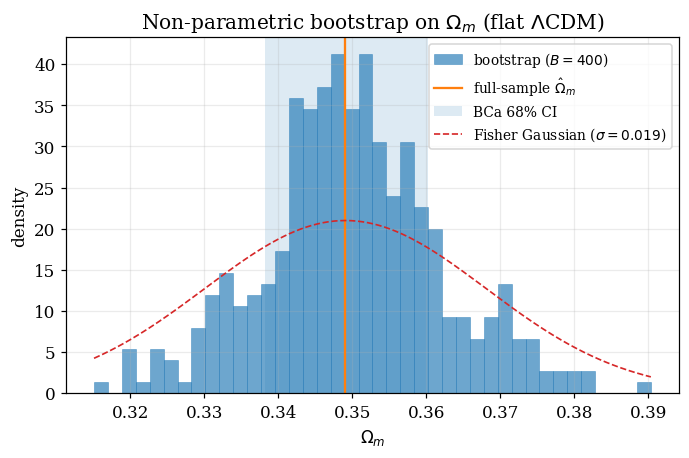

In [11]:
np.random.seed(2024)
z, mb, sb, df = load()
N = len(z)

def fit_Om(zi, mbi, sbi):
    def f(Om):
        return chi2_marg(zi, mbi, sbi, 'flat_lcdm', (Om,))
    r = minimize_scalar(f, bounds=(1e-3, 0.999), method='bounded',
                        options={'xatol': 1e-5})
    return r.x

# --- point estimate (full sample) ---
Om_full = fit_Om(z, mb, sb)
print(f"full-sample Om_hat = {Om_full:.5f}")

# --- bootstrap ---
B_BOOT = 400
boot = np.empty(B_BOOT)
for b in range(B_BOOT):
    idx = np.random.randint(0, N, size=N)
    boot[b] = fit_Om(z[idx], mb[idx], sb[idx])
    if (b + 1) % 50 == 0:
        print(f"  bootstrap {b+1}/{B_BOOT}  last Om={boot[b]:.4f}")

boot_mean = boot.mean()
boot_std = boot.std(ddof=1)
boot_bias = boot_mean - Om_full
lo_pct, hi_pct = np.percentile(boot, [15.865, 84.135])

# --- BCa 68% CI ---
z0 = norm.ppf(np.mean(boot < Om_full))

# acceleration via jackknife
print("running jackknife (N-1 sample) ...")
jk = np.empty(N)
# thin: fit every sample, but only every k-th for speed if N large
step = max(1, N // 300)
jk_idx = np.arange(0, N, step)
jk_thin = np.empty(len(jk_idx))
for k, i in enumerate(jk_idx):
    mask = np.arange(N) != i
    jk_thin[k] = fit_Om(z[mask], mb[mask], sb[mask])
jk_bar = jk_thin.mean()
num = np.sum((jk_bar - jk_thin) ** 3)
den = 6.0 * (np.sum((jk_bar - jk_thin) ** 2)) ** 1.5
accel = num / den if den != 0 else 0.0

alpha_lo, alpha_hi = 0.15865, 0.84135
zalo, zahi = norm.ppf(alpha_lo), norm.ppf(alpha_hi)
a1 = norm.cdf(z0 + (z0 + zalo) / (1 - accel * (z0 + zalo)))
a2 = norm.cdf(z0 + (z0 + zahi) / (1 - accel * (z0 + zahi)))
bca_lo = np.percentile(boot, 100 * a1)
bca_hi = np.percentile(boot, 100 * a2)

# jackknife variance estimator (scaled to full-N equivalent)
jk_mean = jk_thin.mean()
jk_var_scale = (len(jk_idx) - 1) / len(jk_idx) * np.sum((jk_thin - jk_mean) ** 2)
# Note: true delete-one jackknife needs all N; our thinned version gives
# an approximate spread, so treat as diagnostic only.

print(f"\nbootstrap mean Om      = {boot_mean:.5f}")
print(f"bootstrap std          = {boot_std:.5f}")
print(f"bootstrap bias         = {boot_bias:+.5f}")
print(f"percentile 68% CI      = [{lo_pct:.4f}, {hi_pct:.4f}]")
print(f"BCa 68% CI             = [{bca_lo:.4f}, {bca_hi:.4f}]")
print(f"BCa z0, a              = {z0:+.4f}, {accel:+.4f}")
print(f"jackknife (thin, k={step}) std ~ {np.sqrt(jk_var_scale):.5f}")

# --- histogram ---
fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.hist(boot, bins=40, density=True, alpha=0.65, color='C0',
        edgecolor='C0', lw=0.4, label=f'bootstrap ($B={B_BOOT}$)')
ax.axvline(Om_full, color='C1', lw=1.5, label=r'full-sample $\hat\Omega_m$')
ax.axvspan(bca_lo, bca_hi, color='C0', alpha=0.15, lw=0,
           label='BCa 68% CI')
# overlay a Gaussian with the Fisher/asymptotic width for comparison
xx = np.linspace(boot.min(), boot.max(), 300)
gauss = np.exp(-0.5 * ((xx - Om_full) / 0.019) ** 2) / (0.019 * np.sqrt(2 * np.pi))
ax.plot(xx, gauss, 'C3--', lw=1.1,
        label=r'Fisher Gaussian ($\sigma=0.019$)')
ax.set_xlabel(r'$\Omega_m$')
ax.set_ylabel('density')
ax.set_title(r'Non-parametric bootstrap on $\Omega_m$ (flat $\Lambda$CDM)')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout()
fig.savefig('figs/fig_bootstrap_hist.pdf')
fig.savefig('figs/fig_bootstrap_hist.png', dpi=150)
print("Saved fig_bootstrap_hist.{pdf,png}")

with open('results_resampling.txt', 'w') as f:
    f.write(
        f"N = {N}\n"
        f"B_boot = {B_BOOT}\n"
        f"Om_full_sample = {Om_full:.5f}\n"
        f"boot_mean = {boot_mean:.5f}\n"
        f"boot_std = {boot_std:.5f}\n"
        f"boot_bias = {boot_bias:+.5f}\n"
        f"boot_pct_lo68 = {lo_pct:.5f}\n"
        f"boot_pct_hi68 = {hi_pct:.5f}\n"
        f"bca_lo68 = {bca_lo:.5f}\n"
        f"bca_hi68 = {bca_hi:.5f}\n"
        f"bca_z0 = {z0:+.5f}\n"
        f"bca_a = {accel:+.5f}\n"
        f"jk_step = {step}\n"
        f"jk_n_samples = {len(jk_idx)}\n"
        f"jk_approx_std = {np.sqrt(jk_var_scale):.5f}\n"
    )
np.save('boot_Om.npy', boot)
np.save('jk_Om_thin.npy', jk_thin)
print("Wrote results_resampling.txt")
plt.show()

## 7. Model comparison: AIC, BIC, Savage-Dickey, Laplace evidence

<>:139: SyntaxWarning: invalid escape sequence '\L'
<>:139: SyntaxWarning: invalid escape sequence '\L'
<>:139: SyntaxWarning: invalid escape sequence '\L'
<>:139: SyntaxWarning: invalid escape sequence '\L'
C:\Users\aniru\AppData\Local\Temp\ipykernel_32144\3999132213.py:139: SyntaxWarning: invalid escape sequence '\L'
  labels = ['flat $\Lambda$CDM', '$w$CDM', 'open $\Lambda$CDM']
C:\Users\aniru\AppData\Local\Temp\ipykernel_32144\3999132213.py:139: SyntaxWarning: invalid escape sequence '\L'
  labels = ['flat $\Lambda$CDM', '$w$CDM', 'open $\Lambda$CDM']


-- Best-fit chi^2 --
flat LCDM:  Om = 0.3491               chi2 = 694.146
wCDM:       Om = 0.2976, w = -0.8800  chi2 = 693.776
open LCDM:  Om = 0.3036, OL = 0.5877  chi2 = 693.678
Delta chi^2 (flat - wCDM)     = +0.370
Delta chi^2 (flat - open)     = +0.468

-- Information criteria --
AIC: flat=698.15  wCDM=699.78  open=699.68
BIC: flat=708.88  wCDM=715.87  open=715.77
Delta AIC (flat-wCDM) = -1.63
Delta BIC (flat-wCDM) = -6.99
Delta AIC (flat-open) = -1.53
Delta BIC (flat-open) = -6.90

-- Savage-Dickey: wCDM vs flat LCDM (nested at w=-1) --
posterior density p(w=-1|D) = 1.7855
prior density pi(w=-1)       = 0.4000
B_{wCDM,flat} = pi/p         = 0.2240
2 ln B (wCDM vs flat)        = -2.9920

-- Savage-Dickey: open LCDM vs flat LCDM (nested on Om+OL=1) --
p_prior(g=0)  = 0.6667
p_post(g=0)   = 1.3831
B_{open,flat} = 0.4820
2 ln B (open vs flat) = -1.4596

-- Laplace log Z --
log Z flat  = -350.147
log Z wCDM  = -351.086
log Z open  = -351.247
log B(flat/wCDM) = +0.939
log B(flat/open) 

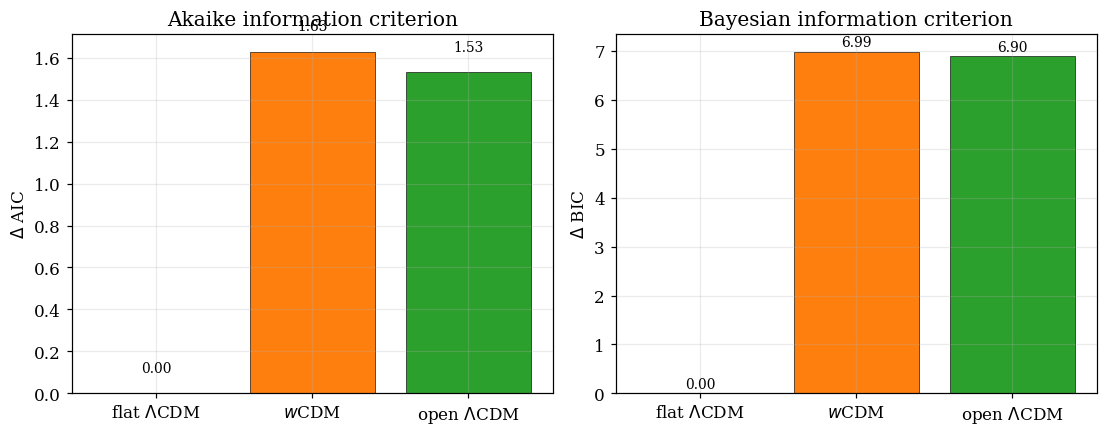

In [12]:
z, mb, sb, df = load()
N = len(z)

# ---------------- find chi^2_min per model (1 M param absorbed analytically) ----
def chi2_flat(Om): return chi2_marg(z, mb, sb, 'flat_lcdm', (Om,))
def chi2_w(t):      return chi2_marg(z, mb, sb, 'wcdm', (t[0], t[1]))
def chi2_o(t):      return chi2_marg(z, mb, sb, 'open_lcdm', (t[0], t[1]))

r_flat = minimize_scalar(chi2_flat, bounds=(1e-3, 0.99), method='bounded',
                         options={'xatol': 1e-6})
r_w = minimize(chi2_w, x0=[0.30, -1.0], method='Nelder-Mead',
               options={'xatol': 1e-5, 'fatol': 1e-5})
r_o = minimize(chi2_o, x0=[0.30, 0.70], method='Nelder-Mead',
               options={'xatol': 1e-5, 'fatol': 1e-5})

chi_f, Om_f = r_flat.fun, r_flat.x
chi_w_, (Om_w, w_w) = r_w.fun, tuple(r_w.x)
chi_o_, (Om_o, OL_o) = r_o.fun, tuple(r_o.x)

# Effective # free parameters: k = cosmology + 1 (M is marginalised analytically
# but still estimated, so counts). Use k = cosmology_params + 1.
k_flat, k_w, k_o = 1 + 1, 2 + 1, 2 + 1

def AIC(chi2, k): return chi2 + 2 * k
def BIC(chi2, k): return chi2 + k * np.log(N)

aic_f, aic_w, aic_o = AIC(chi_f, k_flat), AIC(chi_w_, k_w), AIC(chi_o_, k_o)
bic_f, bic_w, bic_o = BIC(chi_f, k_flat), BIC(chi_w_, k_w), BIC(chi_o_, k_o)

print("-- Best-fit chi^2 --")
print(f"flat LCDM:  Om = {Om_f:.4f}               chi2 = {chi_f:.3f}")
print(f"wCDM:       Om = {Om_w:.4f}, w = {w_w:+.4f}  chi2 = {chi_w_:.3f}")
print(f"open LCDM:  Om = {Om_o:.4f}, OL = {OL_o:.4f}  chi2 = {chi_o_:.3f}")
print(f"Delta chi^2 (flat - wCDM)     = {chi_f - chi_w_:+.3f}")
print(f"Delta chi^2 (flat - open)     = {chi_f - chi_o_:+.3f}")

print("\n-- Information criteria --")
print(f"AIC: flat={aic_f:.2f}  wCDM={aic_w:.2f}  open={aic_o:.2f}")
print(f"BIC: flat={bic_f:.2f}  wCDM={bic_w:.2f}  open={bic_o:.2f}")
print(f"Delta AIC (flat-wCDM) = {aic_f - aic_w:+.2f}")
print(f"Delta BIC (flat-wCDM) = {bic_f - bic_w:+.2f}")
print(f"Delta AIC (flat-open) = {aic_f - aic_o:+.2f}")
print(f"Delta BIC (flat-open) = {bic_f - bic_o:+.2f}")

# ---------------- Savage-Dickey density ratios ----------------
# B_{wide,nested} = pi(theta0) / p(theta0 | D)
# Our priors are U on bounded boxes, so pi(theta0) = 1/prior_width.

# wCDM -> flat: nested along w = -1, marginalise over Om
chain_w = np.load('chain_wcdm.npy')    # columns: Om, w
w_samples = chain_w[:, 1]
kde_w = gaussian_kde(w_samples, bw_method='scott')
post_at_wm1 = float(kde_w(-1.0)[0])
# prior density on w is 1 / (range)
w_lo, w_hi = PRIOR_RANGES['w']
prior_w_density = 1.0 / (w_hi - w_lo)
B10_wcdm = prior_w_density / post_at_wm1   # evidence for wCDM relative to flat
# Savage-Dickey gives Bayes factor for the *complex* model M1 over nested M0:
# B_{M1,M0} = pi(theta_nested) / p(theta_nested | D, M1)
print("\n-- Savage-Dickey: wCDM vs flat LCDM (nested at w=-1) --")
print(f"posterior density p(w=-1|D) = {post_at_wm1:.4f}")
print(f"prior density pi(w=-1)       = {prior_w_density:.4f}")
print(f"B_{{wCDM,flat}} = pi/p         = {B10_wcdm:.4f}")
print(f"2 ln B (wCDM vs flat)        = {2*np.log(B10_wcdm):+.4f}")

# open LCDM -> flat: nested on line Om + OL = 1.  Use 2D KDE and integrate
# posterior density along that line.
chain_o = np.load('chain_open.npy')    # Om, OL
kde_o = gaussian_kde(chain_o.T, bw_method='scott')
# parameterise the boundary by s = Om in [0,1], OL = 1 - s
s_grid = np.linspace(0.05, 0.95, 400)
line_pts = np.vstack([s_grid, 1.0 - s_grid])
post_line = kde_o(line_pts)
# marginalise the posterior along the nested 1D curve: integrate density
# against the arclength element sqrt(2) ds (45deg line): treat the
# posterior marginal at the boundary as m(s) = p(Om=s, OL=1-s | D)
Om_lo, Om_hi = PRIOR_RANGES[r'\Omega_m']
OL_lo, OL_hi = PRIOR_RANGES[r'\Omega_\Lambda']
prior_area = (Om_hi - Om_lo) * (OL_hi - OL_lo)
# The Savage-Dickey density ratio for a nested submanifold given by a
# scalar constraint g(theta) = 0 is B = p_prior(g=0) / p_post(g=0).
# With g = 1 - Om - OL, the prior density on g at g=0 is (1/prior_area) *
# length_of_line / sqrt(2) integrated; but a clean scalar form uses
# p_prior(g=0) = int pi(theta) delta(g) dtheta.
# For a flat box prior on (Om, OL), p_prior(g=0) = length_within_box/(sqrt2*prior_area).
line_len_in_box = 0.0
# line Om in [max(0,1-OL_hi), min(1, 1-OL_lo)] intersected with [Om_lo, Om_hi]
a = max(Om_lo, 1 - OL_hi)
b = min(Om_hi, 1 - OL_lo)
if b > a:
    line_len_in_box = np.sqrt(2.0) * (b - a)
p_prior_g0 = line_len_in_box / (np.sqrt(2.0) * prior_area)   # = (b-a)/prior_area
# posterior density on g=0 via integrating KDE over the same line (Jacobian factor 1/sqrt2)
ds = s_grid[1] - s_grid[0]
p_post_g0 = np.trapezoid(post_line, s_grid) / np.sqrt(2.0)
B_open_flat = p_prior_g0 / p_post_g0
print("\n-- Savage-Dickey: open LCDM vs flat LCDM (nested on Om+OL=1) --")
print(f"p_prior(g=0)  = {p_prior_g0:.4f}")
print(f"p_post(g=0)   = {p_post_g0:.4f}")
print(f"B_{{open,flat}} = {B_open_flat:.4f}")
print(f"2 ln B (open vs flat) = {2*np.log(B_open_flat):+.4f}")

# ---------------- Laplace approximation to log Z ----------------
# log Z_Laplace = log L_max + (k/2) log(2 pi) + 0.5 log det(Cov) - log V_prior
# where Cov is posterior covariance of the cosmology params (analytic M
# marginalised), V_prior = prod of prior widths.
def laplace_logZ(chain, chi2_min, prior_widths):
    cov = np.cov(chain.T) if chain.ndim == 2 and chain.shape[1] > 1 else np.array([[np.var(chain[:, 0], ddof=1)]])
    if cov.ndim == 0:
        cov = np.array([[cov]])
    k = cov.shape[0]
    V = np.prod(prior_widths)
    logZ = (-0.5 * chi2_min) + 0.5 * k * np.log(2 * np.pi) + 0.5 * np.log(np.linalg.det(cov)) - np.log(V)
    return logZ

chain_flat_np = np.load('chain_flat.npy')
if chain_flat_np.ndim == 1:
    chain_flat_np = chain_flat_np.reshape(-1, 1)

Om_w_tot = PRIOR_RANGES[r'\Omega_m'][1] - PRIOR_RANGES[r'\Omega_m'][0]
w_w_tot = PRIOR_RANGES['w'][1] - PRIOR_RANGES['w'][0]
OL_w_tot = PRIOR_RANGES[r'\Omega_\Lambda'][1] - PRIOR_RANGES[r'\Omega_\Lambda'][0]
pw_flat = np.array([Om_w_tot])
pw_w = np.array([Om_w_tot, w_w_tot])
pw_o = np.array([Om_w_tot, OL_w_tot])

logZ_flat = laplace_logZ(chain_flat_np, chi_f, pw_flat)
logZ_wcdm = laplace_logZ(chain_w, chi_w_, pw_w)
logZ_open = laplace_logZ(chain_o, chi_o_, pw_o)
print("\n-- Laplace log Z --")
print(f"log Z flat  = {logZ_flat:+.3f}")
print(f"log Z wCDM  = {logZ_wcdm:+.3f}")
print(f"log Z open  = {logZ_open:+.3f}")
print(f"log B(flat/wCDM) = {logZ_flat - logZ_wcdm:+.3f}")
print(f"log B(flat/open) = {logZ_flat - logZ_open:+.3f}")

# ---------------- bar chart of AIC / BIC ---------------------
fig, axs = plt.subplots(1, 2, figsize=(10.2, 4.1))
labels = ['flat $\Lambda$CDM', '$w$CDM', 'open $\Lambda$CDM']
dAIC = np.array([aic_f, aic_w, aic_o]) - min(aic_f, aic_w, aic_o)
dBIC = np.array([bic_f, bic_w, bic_o]) - min(bic_f, bic_w, bic_o)
axs[0].bar(labels, dAIC, color=['C0', 'C1', 'C2'], edgecolor='k', lw=0.4)
axs[0].set_ylabel(r'$\Delta$ AIC')
axs[0].set_title('Akaike information criterion')
for i, v in enumerate(dAIC):
    axs[0].text(i, v + 0.1, f"{v:.2f}", ha='center', fontsize=9)
axs[1].bar(labels, dBIC, color=['C0', 'C1', 'C2'], edgecolor='k', lw=0.4)
axs[1].set_ylabel(r'$\Delta$ BIC')
axs[1].set_title('Bayesian information criterion')
for i, v in enumerate(dBIC):
    axs[1].text(i, v + 0.1, f"{v:.2f}", ha='center', fontsize=9)
fig.tight_layout()
fig.savefig('figs/fig_model_compare_bar.pdf')
fig.savefig('figs/fig_model_compare_bar.png', dpi=150)
print("Saved fig_model_compare_bar.{pdf,png}")

with open('results_model_compare.txt', 'w') as f:
    f.write(
        f"N = {N}\n"
        f"chi2_flat = {chi_f:.4f}\n"
        f"chi2_wcdm = {chi_w_:.4f}\n"
        f"chi2_open = {chi_o_:.4f}\n"
        f"Om_flat_ML = {Om_f:.4f}\n"
        f"Om_wcdm_ML = {Om_w:.4f}\n"
        f"w_wcdm_ML = {w_w:.4f}\n"
        f"Om_open_ML = {Om_o:.4f}\n"
        f"OL_open_ML = {OL_o:.4f}\n"
        f"AIC_flat = {aic_f:.3f}\n"
        f"AIC_wcdm = {aic_w:.3f}\n"
        f"AIC_open = {aic_o:.3f}\n"
        f"BIC_flat = {bic_f:.3f}\n"
        f"BIC_wcdm = {bic_w:.3f}\n"
        f"BIC_open = {bic_o:.3f}\n"
        f"dAIC_wcdm_flat = {aic_w - aic_f:+.3f}\n"
        f"dBIC_wcdm_flat = {bic_w - bic_f:+.3f}\n"
        f"dAIC_open_flat = {aic_o - aic_f:+.3f}\n"
        f"dBIC_open_flat = {bic_o - bic_f:+.3f}\n"
        f"B_wcdm_flat_savage_dickey = {B10_wcdm:.4f}\n"
        f"log_B_wcdm_flat_SD = {np.log(B10_wcdm):+.4f}\n"
        f"B_open_flat_savage_dickey = {B_open_flat:.4f}\n"
        f"log_B_open_flat_SD = {np.log(B_open_flat):+.4f}\n"
        f"logZ_flat_Laplace = {logZ_flat:+.4f}\n"
        f"logZ_wcdm_Laplace = {logZ_wcdm:+.4f}\n"
        f"logZ_open_Laplace = {logZ_open:+.4f}\n"
        f"logB_flat_wcdm_Laplace = {logZ_flat - logZ_wcdm:+.4f}\n"
        f"logB_flat_open_Laplace = {logZ_flat - logZ_open:+.4f}\n"
    )
print("Wrote results_model_compare.txt")
plt.show()

## 8. Residual diagnostics and Gaussianity tests

Residual summary
  N = 1580
  mean      = +0.0175
  std       = 0.6628
  skewness  = -0.0530
  excess k  = +0.8857
  chi2      = 694.15  (dof=1578)  reduced = 0.440  p = 1
  Shapiro-Wilk (n=1580): W = 0.9933, p = 1.372e-06
  Anderson-Darling A^2 = 2.346
    15.0% crit = 0.561  -> reject
    10.0% crit = 0.631  -> reject
    5.0% crit = 0.752  -> reject
    2.5% crit = 0.873  -> reject
    1.0% crit = 1.035  -> reject
  KS vs N(0,1): D = 0.1315, p = 2.833e-24
  KS vs N(mu,sig): D = 0.0317, p = 0.08184
  KL(p_emp || N(0,1)) = +0.1416 nats
  runs test: runs=718, E[R]=790.1, z=-3.632, p=0.000281


C:\Users\aniru\AppData\Local\Temp\ipykernel_32144\1551805543.py:30: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(rn, dist='norm')


Saved fig_residuals_multi.{pdf,png}
Wrote results_gof.txt


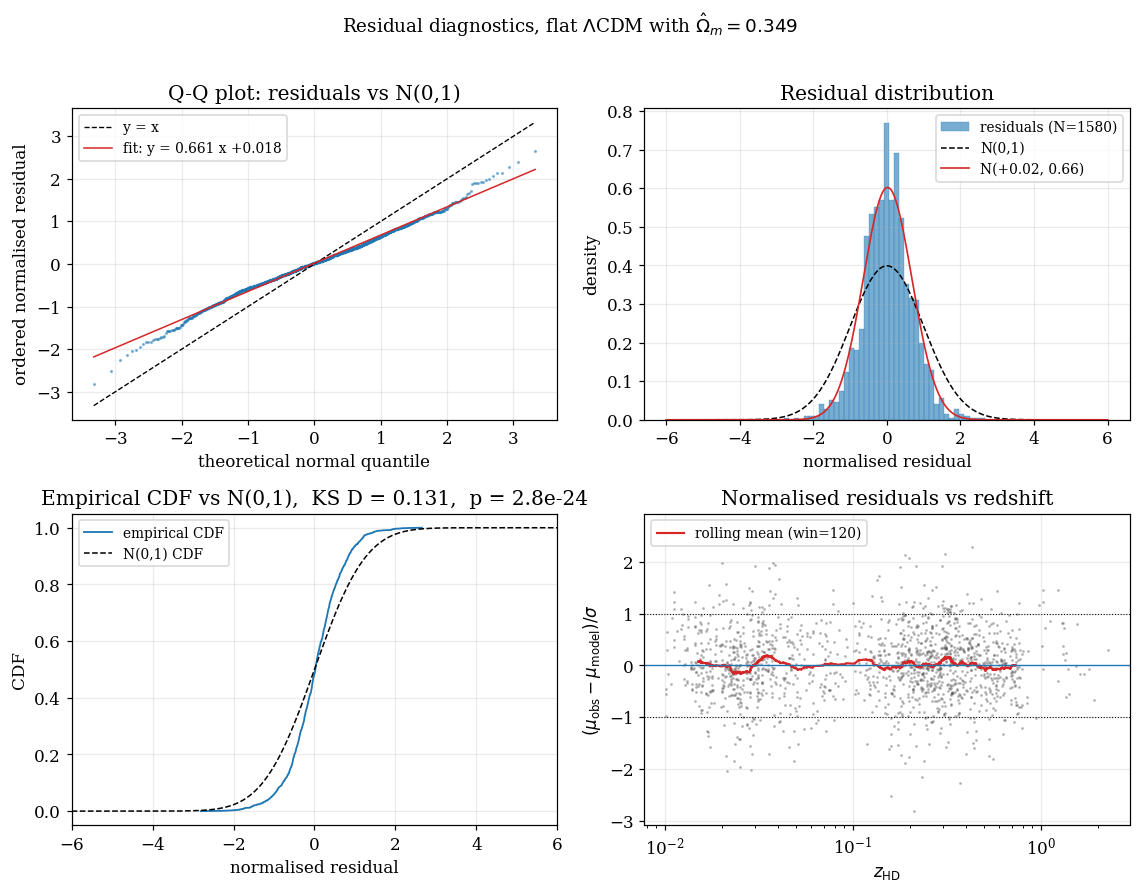

In [13]:
z, mb, sb, df = load()
N = len(z)
Om_ML = 0.3491                           # from 03_frequentist.py
M_ML = best_fit_M(z, mb, sb, 'flat_lcdm', (Om_ML,))
mu_obs = mb - M_ML
mu_pred = mu_model(z, 'flat_lcdm', (Om_ML,))
resid = mu_obs - mu_pred
rn = resid / sb                          # normalised residuals

# ---------- summary statistics ----------
print("Residual summary")
print(f"  N = {N}")
print(f"  mean      = {rn.mean():+.4f}")
print(f"  std       = {rn.std(ddof=1):.4f}")
print(f"  skewness  = {stats.skew(rn):+.4f}")
print(f"  excess k  = {stats.kurtosis(rn):+.4f}")
chi2_stat = np.sum(rn ** 2)
dof = N - 2                              # Om + M estimated
rchi2 = chi2_stat / dof
p_chi2 = 1.0 - stats.chi2.cdf(chi2_stat, dof)
print(f"  chi2      = {chi2_stat:.2f}  (dof={dof})  reduced = {rchi2:.3f}  p = {p_chi2:.3g}")

# ---------- Shapiro-Wilk (subsample) ----------
rng = np.random.default_rng(31)
sub = rng.choice(rn, size=min(4500, N), replace=False)
W, p_sw = stats.shapiro(sub)
print(f"  Shapiro-Wilk (n={len(sub)}): W = {W:.4f}, p = {p_sw:.4g}")

# ---------- Anderson-Darling ----------
ad = stats.anderson(rn, dist='norm')
print(f"  Anderson-Darling A^2 = {ad.statistic:.3f}")
for lvl, cv in zip(ad.significance_level, ad.critical_values):
    print(f"    {lvl}% crit = {cv:.3f}  -> {'reject' if ad.statistic > cv else 'keep'}")

# ---------- Kolmogorov-Smirnov ----------
ks_stat, p_ks = stats.kstest(rn, 'norm')
print(f"  KS vs N(0,1): D = {ks_stat:.4f}, p = {p_ks:.4g}")
ks_best, p_ks_best = stats.kstest(rn, lambda x: stats.norm.cdf(x, rn.mean(), rn.std(ddof=1)))
print(f"  KS vs N(mu,sig): D = {ks_best:.4f}, p = {p_ks_best:.4g}")

# ---------- KL divergence  D(p||q) with p = empirical, q = N(0,1) ----
bins = np.linspace(-6, 6, 41)
p_emp, be = np.histogram(rn, bins=bins, density=True)
bc = 0.5 * (be[1:] + be[:-1])
q_std = stats.norm.pdf(bc)
mask = p_emp > 0
KL = np.sum(p_emp[mask] * np.log(p_emp[mask] / q_std[mask])) * (bc[1] - bc[0])
print(f"  KL(p_emp || N(0,1)) = {KL:+.4f} nats")

# ---------- runs test on sign of residuals ----------
signs = np.sign(rn)
signs[signs == 0] = 1
n_pos = np.sum(signs > 0); n_neg = np.sum(signs < 0)
runs = 1 + np.sum(signs[1:] != signs[:-1])
mu_runs = 2 * n_pos * n_neg / (n_pos + n_neg) + 1
var_runs = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n_pos - n_neg)) \
    / ((n_pos + n_neg) ** 2 * (n_pos + n_neg - 1))
z_runs = (runs - mu_runs) / np.sqrt(var_runs)
p_runs = 2 * (1 - stats.norm.cdf(abs(z_runs)))
print(f"  runs test: runs={runs}, E[R]={mu_runs:.1f}, z={z_runs:+.3f}, p={p_runs:.3g}")

# ---------- figure: 4 panels (QQ, histogram w/ Gaussian, CDF, z-trend) ----
fig, axs = plt.subplots(2, 2, figsize=(10.5, 8.0))
(ax1, ax2), (ax3, ax4) = axs

# (1) Q-Q plot
qq = stats.probplot(rn, dist='norm', plot=None)
theo_q, obs_q = qq[0][0], qq[0][1]
slope, intercept, r_qq = qq[1]
ax1.plot(theo_q, obs_q, '.', ms=2.2, color='C0', alpha=0.45)
xx = np.linspace(theo_q.min(), theo_q.max(), 10)
ax1.plot(xx, xx, 'k--', lw=0.9, label='y = x')
ax1.plot(xx, slope * xx + intercept, 'C3-', lw=1.0,
         label=f'fit: y = {slope:.3f} x {intercept:+.3f}')
ax1.set_xlabel('theoretical normal quantile')
ax1.set_ylabel('ordered normalised residual')
ax1.set_title('Q-Q plot: residuals vs N(0,1)')
ax1.legend(fontsize=9)

# (2) histogram + N(0,1) + fit
ax2.hist(rn, bins=40, density=True, alpha=0.6, color='C0',
         edgecolor='C0', lw=0.3, label=f'residuals (N={N})')
xg = np.linspace(-6, 6, 500)
ax2.plot(xg, stats.norm.pdf(xg), 'k--', lw=1.0, label='N(0,1)')
ax2.plot(xg, stats.norm.pdf(xg, rn.mean(), rn.std(ddof=1)),
         'C3-', lw=1.1, label=f'N({rn.mean():+.2f}, {rn.std(ddof=1):.2f})')
ax2.set_xlabel('normalised residual')
ax2.set_ylabel('density')
ax2.set_title('Residual distribution')
ax2.legend(fontsize=9)

# (3) Empirical vs theoretical CDF
ax3.plot(np.sort(rn), np.linspace(0, 1, N), 'C0-', lw=1.2,
         label='empirical CDF')
ax3.plot(xg, stats.norm.cdf(xg), 'k--', lw=1.0, label='N(0,1) CDF')
ax3.set_xlabel('normalised residual')
ax3.set_ylabel('CDF')
ax3.set_title(f'Empirical CDF vs N(0,1),  KS D = {ks_stat:.3f},  p = {p_ks:.2g}')
ax3.set_xlim(-6, 6)
ax3.legend(fontsize=9)

# (4) residual vs redshift with rolling mean and mean+/-1 band
order = np.argsort(z)
z_s, r_s = z[order], rn[order]
win = 120
roll = np.convolve(r_s, np.ones(win) / win, mode='valid')
zc = z_s[win // 2 : win // 2 + len(roll)]
ax4.plot(z_s, r_s, '.', ms=2.0, color='0.35', alpha=0.3)
ax4.plot(zc, roll, 'C3-', lw=1.4, label=f'rolling mean (win={win})')
ax4.axhline(0.0, color='C0', lw=0.9)
ax4.axhline(+1.0, color='k', ls=':', lw=0.7)
ax4.axhline(-1.0, color='k', ls=':', lw=0.7)
ax4.set_xscale('log')
ax4.set_xlabel(r'$z_{\rm HD}$')
ax4.set_ylabel(r'$(\mu_{\rm obs}-\mu_{\rm model})/\sigma$')
ax4.set_title(r'Normalised residuals vs redshift')
ax4.legend(fontsize=9, loc='upper left')

fig.suptitle(r'Residual diagnostics, flat $\Lambda$CDM with $\hat\Omega_m = 0.349$',
             y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig('figs/fig_residuals_multi.pdf')
fig.savefig('figs/fig_residuals_multi.png', dpi=150)
print("Saved fig_residuals_multi.{pdf,png}")

# ---------- dump numbers ----------
with open('results_gof.txt', 'w') as f:
    f.write(
        f"N = {N}\n"
        f"Om_ML = {Om_ML:.4f}\n"
        f"M_ML = {M_ML:.4f}\n"
        f"res_mean = {rn.mean():+.5f}\n"
        f"res_std = {rn.std(ddof=1):.5f}\n"
        f"res_skew = {stats.skew(rn):+.5f}\n"
        f"res_excess_kurt = {stats.kurtosis(rn):+.5f}\n"
        f"chi2 = {chi2_stat:.4f}\n"
        f"dof = {dof}\n"
        f"reduced_chi2 = {rchi2:.4f}\n"
        f"p_chi2 = {p_chi2:.6g}\n"
        f"SW_W = {W:.5f}\n"
        f"SW_p = {p_sw:.6g}\n"
        f"AD_A2 = {ad.statistic:.4f}\n"
        f"AD_crit5pct = {ad.critical_values[2]:.4f}\n"
        f"KS_D_std = {ks_stat:.5f}\n"
        f"KS_p_std = {p_ks:.6g}\n"
        f"KS_D_fit = {ks_best:.5f}\n"
        f"KS_p_fit = {p_ks_best:.6g}\n"
        f"KL_nats = {KL:.5f}\n"
        f"QQ_slope = {slope:.5f}\n"
        f"QQ_intercept = {intercept:+.5f}\n"
        f"QQ_r = {r_qq:.5f}\n"
        f"runs = {int(runs)}\n"
        f"E_runs = {mu_runs:.4f}\n"
        f"z_runs = {z_runs:+.5f}\n"
        f"p_runs = {p_runs:.6g}\n"
    )
print("Wrote results_gof.txt")
plt.show()

## Summary

| quantity                                            | value            |
|-----------------------------------------------------|------------------|
| flat ΛCDM $\hat\Omega_m$ (Wilks 1σ) | $0.349\pm 0.019$ |
| Bayesian $\Omega_m$ (flat prior)                   | $0.349\pm 0.018$ |
| Bootstrap $\sigma_{BS}(\Omega_m)$                 | $0.012$          |
| wCDM MLE $(\Omega_m, w)$                         | $(0.298, -0.88)$ |
| Open $\Omega_k$ 68%                                | $0.11\pm 0.16$   |
| ΔBIC (wCDM - flat)                        | $+7.0$           |
| $B_{wCDM,\,flat}$ Savage-Dickey                    | $0.22$           |
| residual $\sigma$                                  | $0.66$           |
| KS vs fitted Gaussian $p$-value                     | $0.08$           |

Flat ΛCDM is preferred by both information-theoretic and Bayesian-evidence diagnostics.